# Experiments on the sine dataset

In [1]:
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, parent_dir)

In [2]:
from src.models import (
    LSTMForecaster, 
    MLPForecaster, 
    LinearForecaster, 
    NaiveGaussian, 
    NaiveBootstrap, 
    TransfomerForecaster, 
    GPForecaster,
)
import torch
import matplotlib.pyplot as plt
from sine_utils import plot_forecast, print_metrics

import warnings
warnings.filterwarnings("ignore")

## Data generation

In [3]:
l = 1000
space = torch.linspace(0, 50, l)
target = torch.zeros(l, 2)
target[:, 0] = torch.sin(space)
target[:, 1] = torch.sin(2*space)*2
target = target + torch.randn_like(target)*0.1
split = 0.7
train_target = target[:int(l*split)]
test_target = target[int(l*split):]

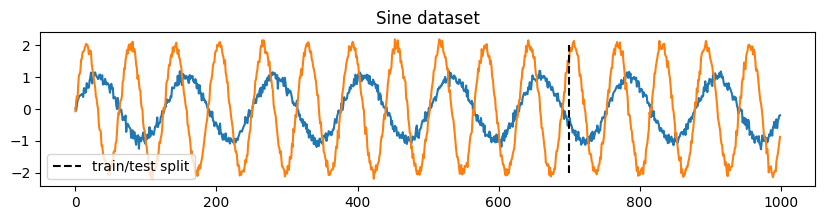

In [4]:
plt.figure(figsize=(10, 2))
plt.plot(target)
plt.vlines(int(l*split), -2, 2, linestyles='dashed', color='black', label='train/test split')
plt.title('Sine dataset')
plt.legend()
plt.show()

## LSTM

In [5]:
model = LSTMForecaster(
    input_len=40, 
    output_len=30, 
    target_dim=2, 
    quantile_levels=[0.025, 0.975],
    batch_size=32,
    num_epochs=50,
    lr=0.01, 
    hidden_dim=32,
)
model

LSTMForecaster(
  (model): LSTMModule(
    (lstm): LSTM(2, 32, batch_first=True)
    (output_projection): Linear(in_features=32, out_features=4, bias=True)
  )
)

In [6]:
train_dataset = model.transform(train_target)
test_dataset = model.transform(test_target)

In [7]:
model.fit(train_dataset)

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type       | Params | Mode 
---------------------------------------------
0 | model | LSTMModule | 4.7 K  | train
---------------------------------------------
4.7 K     Trainable params
0         Non-trainable params
4.7 K     Total params
0.019     Total estimated model params size (MB)
3         Modules in train mode
0         Modules in eval mode


Epoch 49: 100%|██████████████████████| 20/20 [00:00<00:00, 167.77it/s, train_loss=1.020]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████████████████| 20/20 [00:00<00:00, 161.48it/s, train_loss=1.020]


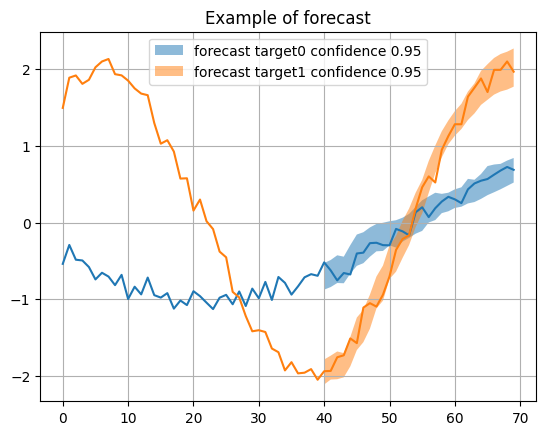

PICP: 0.8733
ECE: 0.0767
CRPS: 0.3803


In [8]:
plot_forecast(model, test_dataset, idx=0)
print_metrics(model, test_dataset)

## MLP

In [9]:
model = MLPForecaster(
    input_len=40, 
    output_len=30, 
    target_dim=2, 
    quantile_levels=[0.025, 0.975],
    batch_size=32,
    num_epochs=50,
    lr=0.01, 
    num_layers=1,
    hidden_dim=128,
)
model

MLPForecaster(
  (model): MLPModule(
    (mlp): Sequential(
      (0): Linear(in_features=2, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=4, bias=True)
    )
  )
)

In [10]:
train_dataset = model.transform(train_target)
test_dataset = model.transform(test_target)

In [11]:
model.fit(train_dataset)

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type      | Params | Mode 
--------------------------------------------
0 | model | MLPModule | 900    | train
--------------------------------------------
900       Trainable params
0         Non-trainable params
900       Total params
0.004     Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode


Epoch 49: 100%|██████████████████████| 20/20 [00:00<00:00, 325.80it/s, train_loss=1.520]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████████████████| 20/20 [00:00<00:00, 310.88it/s, train_loss=1.520]


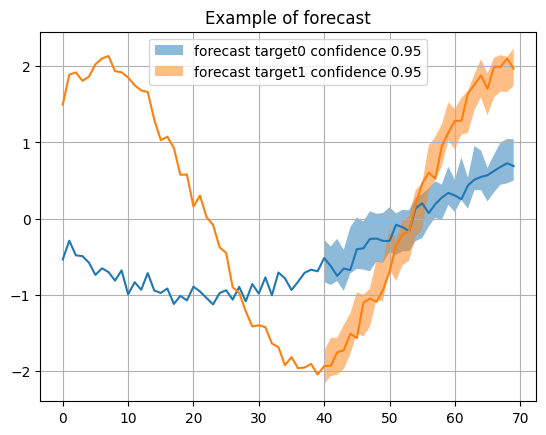

PICP: 0.9302
ECE: 0.0198
CRPS: 0.6842


In [12]:
plot_forecast(model, test_dataset, idx=0)
print_metrics(model, test_dataset)

## Linear

In [13]:
model = LinearForecaster(
    input_len=40, 
    output_len=30, 
    target_dim=2, 
    quantile_levels=[0.025, 0.975],
    batch_size=32,
    num_epochs=50,
    lr=0.1,
)
model

LinearForecaster(
  (model): LinearModule(
    (linear): Linear(in_features=2, out_features=4, bias=True)
  )
)

In [14]:
train_dataset = model.transform(train_target)
test_dataset = model.transform(test_target)

In [15]:
model.fit(train_dataset)

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type         | Params | Mode 
-----------------------------------------------
0 | model | LinearModule | 12     | train
-----------------------------------------------
12        Trainable params
0         Non-trainable params
12        Total params
0.000     Total estimated model params size (MB)
2         Modules in train mode
0         Modules in eval mode


Epoch 49: 100%|██████████████████████| 20/20 [00:00<00:00, 434.21it/s, train_loss=3.270]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████████████████| 20/20 [00:00<00:00, 415.41it/s, train_loss=3.270]


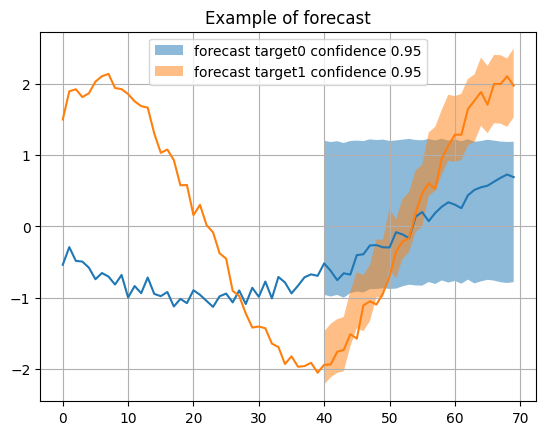

PICP: 0.9318
ECE: 0.0182
CRPS: 1.4730


In [16]:
plot_forecast(model, test_dataset, idx=0)
print_metrics(model, test_dataset)

## Naive Gaussian

In [17]:
model = NaiveGaussian(
    input_len=40, 
    output_len=30, 
    target_dim=2,
    quantile_levels=[0.025, 0.975],
)
model

NaiveGaussian()

In [18]:
train_dataset = model.transform(train_target)
test_dataset = model.transform(test_target)

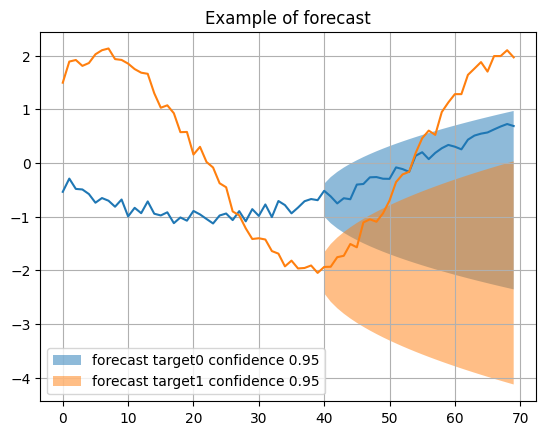

PICP: 0.7363
ECE: 0.2137
CRPS: 2.7120


In [19]:
plot_forecast(model, test_dataset, idx=0)
print_metrics(model, test_dataset)

## Naive Bootstrap

In [20]:
model = NaiveBootstrap(
    input_len=40, 
    output_len=30, 
    target_dim=2,
    quantile_levels=[0.025, 0.975],
    num_samples=1000,
)
model

NaiveBootstrap()

In [21]:
train_dataset = model.transform(train_target)
test_dataset = model.transform(test_target)

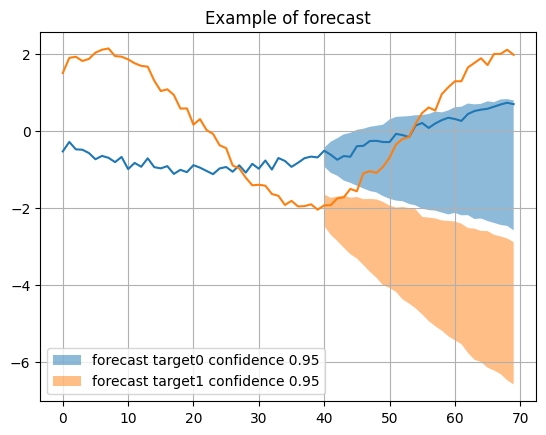

PICP: 0.5931
ECE: 0.3569
CRPS: 3.0475


In [22]:
plot_forecast(model, test_dataset, idx=0)
print_metrics(model, test_dataset)

## Transfomer

In [23]:
model = TransfomerForecaster(
    input_len=40, 
    output_len=30, 
    target_dim=2, 
    quantile_levels=[0.025, 0.975],
    batch_size=32,
    num_epochs=50,
    lr=0.001,
    num_layers=1,
    d_model=64,
    num_heads=1,
    dim_feedforward=32,
    dropout=0.,
)
model

TransfomerForecaster(
  (model): TransformerEncoderModule(
    (input_projection): Linear(in_features=2, out_features=64, bias=True)
    (positional_encoding): PositionalEncoding()
    (transformer_encoder): TransformerEncoder(
      (layers): ModuleList(
        (0): TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
          )
          (linear1): Linear(in_features=64, out_features=32, bias=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (linear2): Linear(in_features=32, out_features=64, bias=True)
          (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.0, inplace=False)
          (dropout2): Dropout(p=0.0, inplace=False)
        )
      )
    )
    (output_projection): Linear(in_features=64, out_features=4, bias=True)
  )
)

In [24]:
train_dataset = model.transform(train_target)
test_dataset = model.transform(test_target)

In [25]:
model.fit(train_dataset)

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type                     | Params | Mode 
-----------------------------------------------------------
0 | model | TransformerEncoderModule | 21.5 K | train
-----------------------------------------------------------
21.5 K    Trainable params
0         Non-trainable params
21.5 K    Total params
0.086     Total estimated model params size (MB)
16        Modules in train mode
0         Modules in eval mode


Epoch 49: 100%|██████████████████████| 20/20 [00:00<00:00, 230.85it/s, train_loss=1.230]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████████████████| 20/20 [00:00<00:00, 221.49it/s, train_loss=1.230]


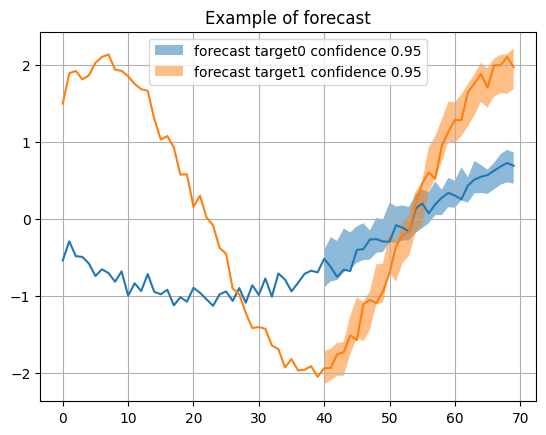

PICP: 0.9357
ECE: 0.0143
CRPS: 0.4931


In [26]:
plot_forecast(model, test_dataset, idx=0)
print_metrics(model, test_dataset)

## Gaussian process

In [27]:
model = GPForecaster(
    input_len=40, 
    output_len=30, 
    target_dim=2, 
    quantile_levels=[0.025, 0.975],
    batch_size=32,
    num_epochs=50,
    lr=0.01,
    num_inducing=100,
)
model

GPForecaster(
  (model): GPModule(
    (mean_linear): Linear(in_features=100, out_features=2, bias=True)
    (var_linear): Linear(in_features=100, out_features=2, bias=True)
  )
)

In [28]:
train_dataset = model.transform(train_target)
test_dataset = model.transform(test_target)

In [29]:
model.fit(train_dataset)

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type     | Params | Mode 
-------------------------------------------
0 | model | GPModule | 604    | train
-------------------------------------------
604       Trainable params
0         Non-trainable params
604       Total params
0.002     Total estimated model params size (MB)
3         Modules in train mode
0         Modules in eval mode


Epoch 49: 100%|██████████████████████| 20/20 [00:00<00:00, 262.60it/s, train_loss=1.680]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████████████████| 20/20 [00:00<00:00, 253.01it/s, train_loss=1.680]


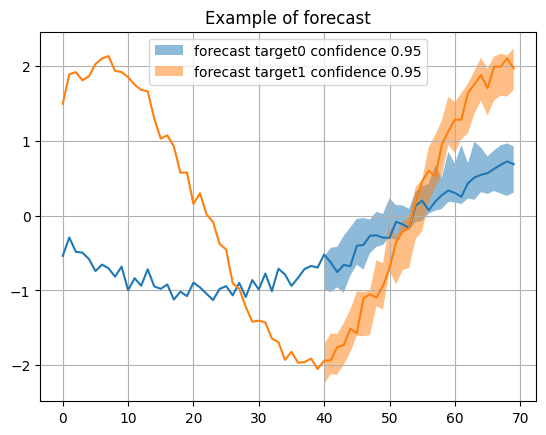

PICP: 0.9393
ECE: 0.0107
CRPS: 0.7868


In [30]:
plot_forecast(model, test_dataset, idx=0)
print_metrics(model, test_dataset)